<a href="https://colab.research.google.com/github/catSushiRoll/BSProjek/blob/main/CNN_Epileptic_EEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS TPIB 2024/2025 (Bagian B)

Contains CNN program to classify epileptic based on EEG signals
<br>Link to dataset : https://www.ukbonn.de/epileptologie/arbeitsgruppen/ag-lehnertz-neurophysik/downloads/#:~:text=



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install tensorflow

### Conversion File to CSV
This code is to make a CSV version of the dataset given

In [ ]:
import os
import numpy as np
import pandas as pd

def read_signal_from_txt(file_path):
    with open(file_path, 'r') as f:
        data = f.readlines()
    data = [float(line.strip()) for line in data]
    return data

def load_dataset_from_folder(folder_path, label):
    rows = []
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.txt'):
            file_path = os.path.join(folder_path, filename)
            signal = read_signal_from_txt(file_path)
            if len(signal) == 4097 or len(signal) == 4098:
                if signal:
                    rows.append([label] + signal)
                else:
                    print(f"Warning: File {filename} is empty or contains no valid float data.")
    return rows

base_path = "/content/drive/MyDrive/dataset eeg"

categories = {
    'Z': 0, # non-epileptic
    'O': 0, # non-epileptic
    'N': 0, # non-epileptic
    'F': 0, # non-epileptic
    'S': 1   # epileptic
}

all_data = []

for folder, label in categories.items():
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        data = load_dataset_from_folder(folder_path, label)
        all_data.extend(data)
    else:
        print(f"Warning: Directory not found: {folder_path}")

df = pd.DataFrame(all_data)

if not df.empty:
    output_path = os.path.join('/content/drive/MyDrive/dataset eeg', 'EEG_epilepsy_dataset.csv')
    num_data_cols = df.shape[1] - 1 if df.shape[1] > 0 else 0
    header = ["label"] + [f"v{i}" for i in range(1, num_data_cols + 1)]

    if len(header) == df.shape[1]:
        df.to_csv(output_path, index=False, header=header)
        print(f"Conversion done. Datasets saved in {output_path}")
    else:
        print(f"Error: Header length ({len(header)}) does not match DataFrame columns ({df.shape[1]}). Cannot save CSV.")

else:
    print("No data was loaded from the specified folders. CSV not saved.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5242 - loss: 0.9723 - val_accuracy: 0.7750 - val_loss: 0.5300
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8701 - loss: 0.3877 - val_accuracy: 0.9250 - val_loss: 0.2031
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 981ms/step - accuracy: 0.9723 - loss: 0.0959 - val_accuracy: 0.9500 - val_loss: 0.0982
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9638 - loss: 0.0939 - val_accuracy: 0.9250 - val_loss: 0.1257
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9984 - loss: 0.0302 - val_accuracy: 0.9250 - val_loss: 0.1886
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9979 - loss: 0.0176 - val_accuracy: 0.9750 - val_loss: 0.1003
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9914 - loss: 0.0166 - val_accuracy: 0.9375 - val_loss: 0.1549
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9625 - val_lo

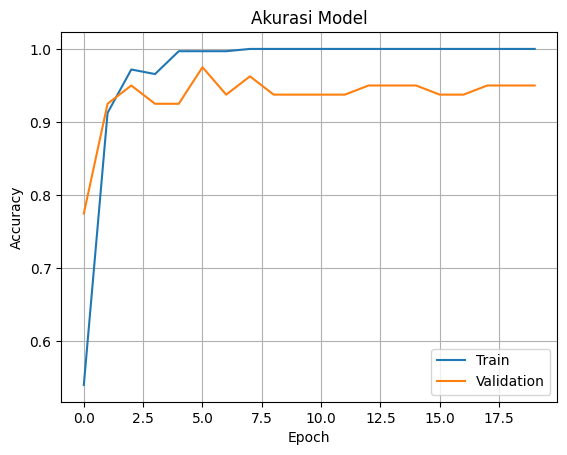

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.9633 - loss: 0.1149
Akurasi pada data uji: 0.95


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/dataset eeg/EEG_epilepsy_dataset.csv")
X = df.drop('label', axis=1).values
y = df['label'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = X.reshape(X.shape[0], X.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(256, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi pada data uji: {acc:.2f}")
